# Historical Innovation Notebook for Contrastive IG Analysis

This notebook proposes **new historical analysis angles** on top of the existing integrated-gradients workflow for masked-token contrast (e.g., machine vs slave).

It is designed as a companion to `example_analysis_colab.ipynb` and uses the same data files.

## What this adds
1. Temporal rupture detection (when lexical influence abruptly changes).
2. Genre-conditioned divergence (when contrastive semantics split by genre).
3. Bridge-token network (tokens linking both conceptual fields).
4. Token career trajectories (rise/fall and allegiance switching over decades).
5. Microhistory evidence packs (historian-ready sentence dossiers for close reading).

In [ ]:
!gdown --folder 1DEtOJg4NmJok40MHje68N-K-JPPm1bfD
!mv /content/ExperimentsData/* .
!rm -r /content/ExperimentsData

In [ ]:
!git clone https://github.com/Text-Machine/mask-predict.git

In [ ]:
%cd mask-predict

In [ ]:
!pip install -q -e .

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.spatial.distance import jensenshannon

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)

In [ ]:
# Configuration
root = Path('.')
dataPath = root / 'masking_data'
processedFolder = root / 'processed_data'

collection = 'blb'
TargetMaskedToken = 'machine'
ContrastiveMaskedToken = 'slave'
genre_suffix = '_with_genre' if collection == 'blb' else ''
mask2tokens = {'machine': ['machine', 'machines'], 'slave': ['slave', 'slaves']}


Loaded:
df_sent: (131002, 33)
df_ig:   (11008832, 4)
Date range: 1783 - 1900


In [ ]:
!unzip -o "/content/{collection}_{TargetMaskedToken}_clusters{genre_suffix}.tsv.zip"
!unzip -o "/content/results_{collection}_{TargetMaskedToken}_constrastive.csv.zip"
!unzip -o "/content/{collection}_{ContrastiveMaskedToken}_clusters{genre_suffix}.tsv.zip"
!unzip -o "/content/results_{collection}_{ContrastiveMaskedToken}_constrastive.csv.zip"

In [ ]:

df_sent = pd.read_csv(dataPath / f'{collection}_{TargetMaskedToken}_clusters{genre_suffix}.tsv', sep='\t', index_col=0)
df_ig = pd.read_csv(processedFolder / f'results_{collection}_{TargetMaskedToken}_constrastive.csv', index_col=0)

print('Loaded:')
print('df_sent:', df_sent.shape)
print('df_ig:  ', df_ig.shape)
print('Date range:', int(df_sent['date'].min()), '-', int(df_sent['date'].max()))

In [3]:
# Build observed and counterfactual partitions as in the original notebook
df_obs = df_ig[df_ig['Target'].isin(mask2tokens[TargetMaskedToken])].copy().reset_index(drop=True)
df_cf = df_ig[df_ig['Target'].isin(mask2tokens[ContrastiveMaskedToken])].copy().reset_index(drop=True)

print('Observed rows:', len(df_obs))
print('Counterfactual rows:', len(df_cf))

if len(df_obs) != len(df_cf):
    raise ValueError('Observed and counterfactual tables differ in length; cannot compute row-wise contrast safely.')

df_obs['cf_score'] = df_cf['Score'].values
df_obs['diff_score'] = df_obs['Score'] - df_obs['cf_score']

df_obs.head()

Observed rows: 5504416
Counterfactual rows: 5504416


,Token,Score,Target,id,cf_score,diff_score
0,the,0.055053,machine,60000,0.078451,-0.023398
1,[MASK],0.000000,machine,60000,0.000000,0.000000
2,shops,0.330447,machine,60000,0.113365,0.217082
3,occupy,-0.067776,machine,60000,-0.013851,-0.053925
4,three,0.071201,machine,60000,0.087737,-0.016536


## 1) Temporal Rupture Detection

Instead of static top-words, detect **when** token influence suddenly changes.

Historical use: this can surface moments of discursive transition (policy shocks, wars, labor conflict, technological diffusion).

In [4]:
# Merge decade from sentence metadata
dec_map = df_sent[['date']].copy()
dec_map['decade'] = (dec_map['date'].astype(int) // 10) * 10
df_long = df_obs.join(dec_map, on='id', how='left')

In [5]:


# Focus on frequent tokens for stability
min_count = 100
tok_counts = df_long['Token'].value_counts()
stable_tokens = tok_counts[tok_counts >= min_count].index

trend = (
    df_long[df_long['Token'].isin(stable_tokens)]
    .groupby(['Token', 'decade'])['diff_score']
    .mean()
    .rename('mean_diff')
    .reset_index()
)

trend.head()

,Token,decade,mean_diff
0,!,1780,0.023598
1,!,1790,0.014233
2,!,1800,0.038656
3,!,1810,0.026428
4,!,1820,0.016562


In [6]:
# Rolling z-score per token to flag abrupt changes
def add_rupture_flags(g):
    g = g.sort_values('decade').copy()
    roll_mean = g['mean_diff'].rolling(3, min_periods=3).mean()
    roll_std = g['mean_diff'].rolling(3, min_periods=3).std()
    g['rupture_z'] = (g['mean_diff'] - roll_mean) / roll_std.replace(0, np.nan)
    g['rupture_abs_z'] = g['rupture_z'].abs()
    return g

In [7]:
trend_flagged = trend.groupby('Token', group_keys=True).apply(add_rupture_flags)
trend_flagged.head()

decade  mean_diff  rupture_z  rupture_abs_z
Token                                               
!     0    1780   0.023598        NaN            NaN
      1    1790   0.014233        NaN            NaN
      2    1800   0.038656   1.068062       1.068062
      3    1810   0.026428  -0.000907       0.000907
      4    1820   0.016562  -0.962525       0.962525

In [8]:





ruptures = trend_flagged.dropna(subset=['rupture_abs_z']).sort_values('rupture_abs_z', ascending=False)
ruptures.head(25)

,,decade,mean_diff,rupture_z,rupture_abs_z
Token,,,,,
pyrites,28135,1840,-0.005964,1.154701,1.154701
manufac,21611,1810,0.027003,1.154701,1.154701
feature,14175,1820,0.027117,-1.154701,1.154701
perforated,25847,1830,-0.010716,1.154701,1.154701
happen,16884,1810,0.009496,-1.154701,1.154701
performance,25867,1830,0.079330,1.154701,1.154701
astonishment,3491,1880,0.022934,-1.154701,1.154701
ah,2248,1870,0.011911,1.154701,1.154701
coarse,7657,1870,-0.023671,1.154701,1.154701


## 2) Genre-Conditioned Semantic Divergence (between observed and counterfactual)

Measure whether the observed-vs-counterfactual lexical field diverges differently by genre.

Historical use: identifies where and when the conceptual opposition is most intense.

In [9]:
genre_col = 'genre'

meta = df_sent[[genre_col]].copy()
long_obs = df_obs.join(meta, on='id', how='left')
long_cf = df_cf.join(meta, on='id', how='left')

def genre_token_distribution(df_part, g):
    x = df_part[df_part[genre_col] == g].groupby('Token')['Score'].mean()
    x = x.clip(lower=0)
    if x.sum() == 0:
        return x
    return x / x.sum()

rows = []
for g in long_obs[genre_col].dropna().value_counts().index:
    p = genre_token_distribution(long_obs, g)
    q = genre_token_distribution(long_cf, g)

    vocab = p.index.union(q.index)
    p = p.reindex(vocab, fill_value=0)
    q = q.reindex(vocab, fill_value=0)

    if p.sum() == 0 or q.sum() == 0:
        js = np.nan
    else:
        js = jensenshannon(p.values, q.values, base=2)

    rows.append({
            'genre': g,
            'n_sentences': int((df_sent[genre_col] == g).sum()),
            'js_divergence_obs_vs_cf': float(js) if pd.notna(js) else np.nan
    })

df_genre = pd.DataFrame(rows)#.sort_values('js_divergence_obs_vs_cf', ascending=False).head(20)

In [10]:
df_genre

,genre,n_sentences,js_divergence_obs_vs_cf
0,Non-fiction,100779,0.305358
1,Fiction,30223,0.323263


In [11]:
# Genre-conditioned semantic divergence by decade
# Requires: long_obs, long_cf, genre_col, and df_sent from the previous cells.

if 'date' not in df_sent.columns:
    raise ValueError("df_sent must contain a 'date' column to compute decade-level divergence.")

# Attach decade to observed/counterfactual long tables
decade_meta = df_sent[['date']].copy()
decade_meta['decade'] = (decade_meta['date'].astype(int) // 10) * 10

long_obs_dec = long_obs.join(decade_meta[['decade']], on='id', how='left')
long_cf_dec = long_cf.join(decade_meta[['decade']], on='id', how='left')

def decade_genre_distribution(df_part, decade_value, genre_value):
    subset = df_part[(df_part['decade'] == decade_value) & (df_part[genre_col] == genre_value)]
    x = subset.groupby('Token')['Score'].mean()
    x = x.clip(lower=0)
    if x.sum() == 0:
        return x
    return x / x.sum()

min_sentences = 25  # filter sparse decade-genre cells for more stable estimates
rows_dec = []

for decade_value in sorted(long_obs_dec['decade'].dropna().unique()):
    genres_in_decade = long_obs_dec.loc[long_obs_dec['decade'] == decade_value, genre_col].dropna().value_counts().index
    for genre_value in genres_in_decade:
        n_sent = int(((df_sent['date'].astype(int) // 10) * 10 == decade_value).mul(df_sent[genre_col] == genre_value).sum())
        if n_sent < min_sentences:
            continue

        p = decade_genre_distribution(long_obs_dec, decade_value, genre_value)
        q = decade_genre_distribution(long_cf_dec, decade_value, genre_value)

        vocab = p.index.union(q.index)
        p = p.reindex(vocab, fill_value=0)
        q = q.reindex(vocab, fill_value=0)

        if p.sum() == 0 or q.sum() == 0:
            js = np.nan
        else:
            js = jensenshannon(p.values, q.values, base=2)

        rows_dec.append({
            'decade': int(decade_value),
            'genre': genre_value,
            'n_sentences': n_sent,
            'js_divergence_obs_vs_cf': float(js) if pd.notna(js) else np.nan
        })

df_genre_decade = pd.DataFrame(rows_dec).sort_values(['decade', 'js_divergence_obs_vs_cf'], ascending=[True, False])

print('Top decade-genre divergences (highest JS):')
display(df_genre_decade.sort_values('js_divergence_obs_vs_cf', ascending=False).head(25))

print('Pivot view (rows=decade, cols=genre, values=JS divergence):')
display(df_genre_decade.pivot(index='decade', columns='genre', values='js_divergence_obs_vs_cf'))

Top decade-genre divergences (highest JS):


,decade,genre,n_sentences,js_divergence_obs_vs_cf
10,1830,Fiction,313,0.379913
2,1790,Non-fiction,55,0.375486
1,1790,Fiction,124,0.367545
0,1780,Fiction,38,0.367537
8,1820,Fiction,565,0.361742
4,1800,Fiction,364,0.359020
18,1870,Fiction,4171,0.358204
16,1860,Fiction,2821,0.355669
14,1850,Fiction,1958,0.352795
12,1840,Fiction,853,0.349950


Pivot view (rows=decade, cols=genre, values=JS divergence):


genre,Fiction,Non-fiction
decade,,
1780,0.367537,NaN
1790,0.367545,0.375486
1800,0.359020,0.345256
1810,0.346681,0.345855
1820,0.361742,0.346011
1830,0.379913,0.347423
1840,0.349950,0.346734
1850,0.352795,0.345167
1860,0.355669,0.341498


<Axes: xlabel='decade'>

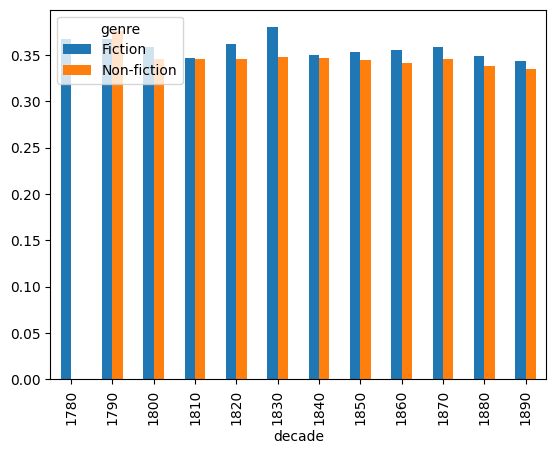

In [12]:

df_genre_decade.pivot(index='decade', columns='genre', values='js_divergence_obs_vs_cf').plot(kind='bar')


## 3) Bridge-Token Network

Find tokens that are high contributors to both target and contrastive predictions, then rank by a **bridge index**.

Historical use: bridge tokens often indicate conceptual transfer zones where discourses overlap or hybridize.

In [13]:
agg_obs = df_obs.groupby('Token').agg(obs_mean=('Score', 'mean'), obs_count=('Score', 'size'))
agg_cf = df_cf.groupby('Token').agg(cf_mean=('Score', 'mean'), cf_count=('Score', 'size'))
bridge = agg_obs.join(agg_cf, how='inner')

min_count = 25
bridge = bridge[(bridge['obs_count'] >= min_count) & (bridge['cf_count'] >= min_count)].copy()

# Bridge index rewards high contribution to both sides and penalizes imbalance
bridge['balance'] = 1 - (bridge['obs_mean'] - bridge['cf_mean']).abs() / (bridge['obs_mean'].abs() + bridge['cf_mean'].abs() + 1e-9)
bridge['bridge_index'] = np.sqrt(np.maximum(bridge['obs_mean'], 0) * np.maximum(bridge['cf_mean'], 0)) * bridge['balance']

bridge.sort_values('bridge_index', ascending=False).head(40)

,obs_mean,obs_count,cf_mean,cf_count,balance,bridge_index
Token,,,,,,
pendulum,0.303678,45,0.275729,45,0.951762,0.275408
soulless,0.336674,31,0.269013,31,0.888291,0.267329
infernal,0.262488,1314,0.291107,1314,0.948302,0.262137
kneading,0.256201,31,0.249482,31,0.986713,0.249460
blackwood,0.257121,36,0.241574,36,0.968824,0.241456
glove,0.266015,37,0.240952,37,0.950562,0.240657
unoiled,0.240341,53,0.277538,53,0.928174,0.239720
ry,0.265417,160,0.237156,160,0.943768,0.236781
cone,0.282357,69,0.236143,69,0.910871,0.235203


## 4) Token Career Trajectories and Allegiance Switching

Estimate each token's long-run trend in contrastive leaning over decades and detect sign changes in mean difference.

Historical use: identifies terms that migrate from one semantic pole to the other over time.

In [14]:
token_dec = (
    df_long.groupby(['Token', 'decade'])['diff_score']
    .mean()
    .reset_index()
)

token_dec.head()   

,Token,decade,diff_score
0,!,1780,0.023598
1,!,1790,0.014233
2,!,1800,0.038656
3,!,1810,0.026428
4,!,1820,0.016562


In [15]:
def token_trajectory_stats(g):
    g = g.sort_values('decade')
    if len(g) < 4:
        return pd.Series({'n_decades': len(g), 'slope_per_decade': np.nan, 'switches': np.nan})
    x = g['decade'].values
    y = g['diff_score'].values
    slope = np.polyfit(x, y, 1)[0]
    signs = np.sign(y)
    switches = int(np.sum((signs[1:] * signs[:-1]) < 0))
    return pd.Series({'n_decades': len(g), 'slope_per_decade': slope, 'switches': switches})

In [16]:
traj = token_dec.groupby('Token').apply(token_trajectory_stats)
traj.head()

,n_decades,slope_per_decade,switches
Token,,,
!,13.0,-0.000067,0.0
"""",13.0,-0.000162,0.0
#,9.0,0.000667,3.0
$,10.0,-0.000064,2.0
%,8.0,-0.000338,1.0


In [17]:
freq = df_long['Token'].value_counts().rename('freq')
traj = traj.join(freq, how='left')

In [18]:


print('Strong positive slope (leaning increasingly toward target concept):')
display(traj[traj['freq'] >= 100].sort_values('slope_per_decade', ascending=False).head(20))

print('Strong negative slope (leaning increasingly toward counterfactual concept):')
display(traj[traj['freq'] >= 100].sort_values('slope_per_decade', ascending=True).head(20))


Strong positive slope (leaning increasingly toward target concept):


,n_decades,slope_per_decade,switches,freq
Token,,,,
sewing,8.0,0.007377,1.0,3870
singer,5.0,0.004986,0.0,374
automatically,4.0,0.003292,1.0,120
ventilation,6.0,0.003263,3.0,140
knitting,8.0,0.003032,1.0,307
majority,9.0,0.002913,2.0,111
400,10.0,0.002804,1.0,396
tank,8.0,0.002797,1.0,135
seam,6.0,0.002703,3.0,125


Strong negative slope (leaning increasingly toward counterfactual concept):


,n_decades,slope_per_decade,switches,freq
Token,,,,
breakers,8.0,-0.006982,4.0,113
reapers,6.0,-0.004209,2.0,179
shaping,7.0,-0.003632,2.0,142
blasting,7.0,-0.003275,0.0,171
torpedo,9.0,-0.002445,0.0,121
however,11.0,-0.002351,5.0,1992
fires,10.0,-0.002341,0.0,190
amid,8.0,-0.002258,3.0,105
chamber,11.0,-0.002241,0.0,230


In [19]:

print('High switching tokens (semantic instability):')
display(traj[traj['freq'] >= 100].sort_values('switches', ascending=False).head(20))

High switching tokens (semantic instability):


,n_decades,slope_per_decade,switches,freq
Token,,,,
hope,13.0,-0.000978,9.0,391
passion,12.0,-0.000037,8.0,102
connected,10.0,-0.000020,8.0,767
nearly,11.0,-0.000049,8.0,1359
face,12.0,-0.000267,8.0,909
ruin,10.0,0.000199,8.0,108
course,13.0,-0.000041,8.0,1484
circumstance,11.0,-0.000199,8.0,126
formed,11.0,-0.000020,8.0,959


### Interpreting Section 4: From Token Careers to Representative Sentences

The next cells help you move from token-level trajectory metrics to interpretable evidence:
- classify trajectory types (rising, falling, switching, stable),
- visualize representative token careers over decades,
- retrieve typical and contrastive sentence examples for selected tokens and decades.

In [20]:
# 4A) Build interpretable trajectory groups
analysis_min_freq = 150
traj_view = traj[traj['freq'] >= analysis_min_freq].copy()
traj_view['abs_slope'] = traj_view['slope_per_decade'].abs()

In [21]:
traj_view[['slope_per_decade','abs_slope']][:10]

,slope_per_decade,abs_slope
Token,,
!,-6.663034e-05,6.663034e-05
"""",-1.623739e-04,1.623739e-04
$,-6.405442e-05,6.405442e-05
&,-2.072489e-05,2.072489e-05
',-9.850856e-05,9.850856e-05
(,1.039761e-04,1.039761e-04
),8.140359e-05,8.140359e-05
*,3.020060e-04,3.020060e-04
",",7.398365e-07,7.398365e-07


In [22]:
slope_cut = traj_view['abs_slope'].quantile(0.80)
switch_cut = max(1, int(traj_view['switches'].quantile(0.90)))
print(f"Tokens with slope magnitude >= {slope_cut:.4f} or switches >= {switch_cut} will be flagged for interpretability analysis.")

Tokens with slope magnitude >= 0.0005 or switches >= 5 will be flagged for interpretability analysis.


In [23]:




def classify_token(row):
    if pd.notna(row['switches']) and row['switches'] >= switch_cut:
        return 'volatile_switching'
    if pd.notna(row['slope_per_decade']) and row['slope_per_decade'] >= slope_cut:
        return 'rising_target'
    if pd.notna(row['slope_per_decade']) and row['slope_per_decade'] <= -slope_cut:
        return 'rising_counterfactual'
    return 'stable_or_mixed'

traj_view['trajectory_group'] = traj_view.apply(classify_token, axis=1)

print('Trajectory groups (freq >=', analysis_min_freq, '):')
display(traj_view['trajectory_group'].value_counts())

print('Representative tokens by group:')
rep_tokens = (
    traj_view
    .sort_values(['trajectory_group', 'abs_slope', 'switches'], ascending=[True, False, False])
    .groupby('trajectory_group')
    .head(8)
    .reset_index()
)
display(rep_tokens[['Token', 'trajectory_group', 'freq', 'slope_per_decade', 'switches']])

Trajectory groups (freq >= 150 ):


trajectory_group
stable_or_mixed          1973
volatile_switching        397
rising_target             311
rising_counterfactual     207
Name: count, dtype: int64

Representative tokens by group:


,Token,trajectory_group,freq,slope_per_decade,switches
0,reapers,rising_counterfactual,179,-0.004209,2.0
1,blasting,rising_counterfactual,171,-0.003275,0.0
2,fires,rising_counterfactual,190,-0.002341,0.0
3,chamber,rising_counterfactual,230,-0.002241,0.0
4,telegraph,rising_counterfactual,172,-0.002235,0.0
5,vast,rising_counterfactual,900,-0.002099,0.0
6,trough,rising_counterfactual,270,-0.002088,4.0
7,elaborate,rising_counterfactual,199,-0.002057,0.0
8,sewing,rising_target,3870,0.007377,1.0
9,singer,rising_target,374,0.004986,0.0


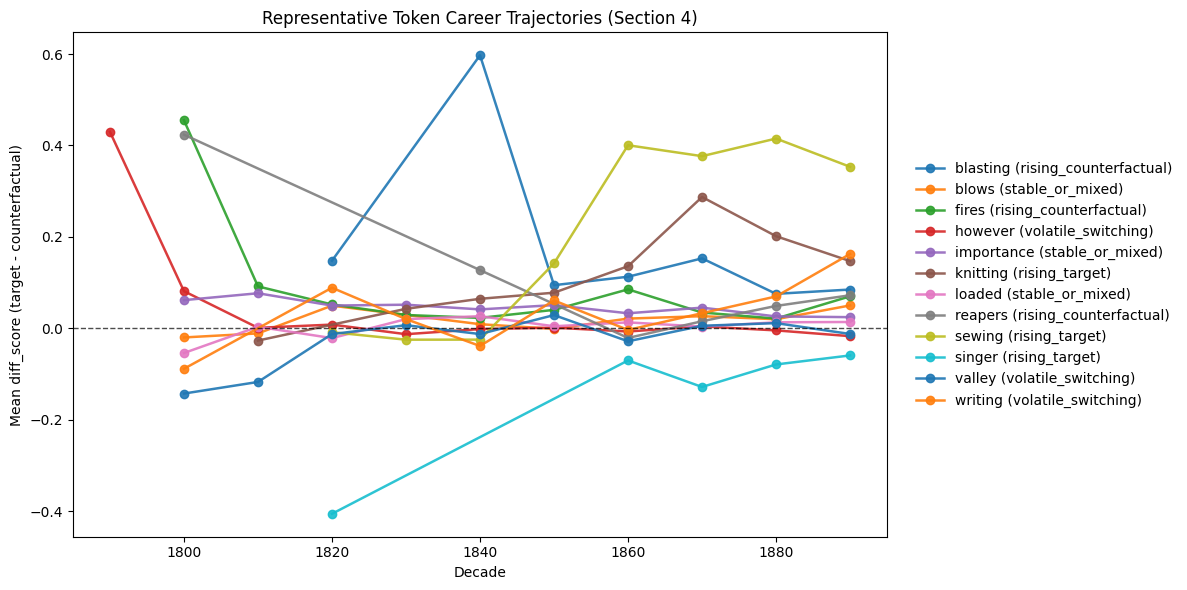

In [36]:
# 4B) Visualize representative token careers by trajectory group
import matplotlib.pyplot as plt

# Pick up to 3 representative tokens per group
plot_tokens = (
    rep_tokens
    .groupby('trajectory_group')['Token']
    .head(3)
    .tolist()
)

plot_df = token_dec[token_dec['Token'].isin(plot_tokens)].copy()
plot_df = plot_df.sort_values(['trajectory_group' if 'trajectory_group' in plot_df.columns else 'Token', 'Token', 'decade'])

# Attach trajectory group labels to plotting table
plot_df = plot_df.merge(
    rep_tokens[['Token', 'trajectory_group']].drop_duplicates(),
    on='Token',
    how='left'
)

fig, ax = plt.subplots(figsize=(12, 6))
for token, g in plot_df.groupby('Token'):
    label = f"{token} ({g['trajectory_group'].iloc[0]})"
    ax.plot(g['decade'], g['diff_score'], marker='o', linewidth=1.8, alpha=0.9, label=label)

ax.axhline(0, linestyle='--', linewidth=1, color='black', alpha=0.7)
ax.set_title('Representative Token Career Trajectories (Section 4)')
ax.set_xlabel('Decade')
ax.set_ylabel('Mean diff_score (target - counterfactual)')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()

In [40]:
# 4C) Retrieve typical and contrastive sentence exemplars for selected trajectory tokens
text_col = next((c for c in ['maskedSentence', 'sentence', 'text', 'context'] if c in df_sent.columns), None)
if text_col is None:
    raise ValueError('No sentence text column found in df_sent. Expected one of: maskedSentence, sentence, text, context.')

meta_cols_for_examples = ['date']
if 'genre' in df_sent.columns:
    meta_cols_for_examples.append('genre')
meta_cols_for_examples.append(text_col)

obs_with_meta = df_obs.join(df_sent[meta_cols_for_examples], on='id', how='left')
obs_with_meta['decade'] = (obs_with_meta['date'].astype(int) // 10) * 10

def get_examples_for_token(token, decade, k=3):
    subset = obs_with_meta[(obs_with_meta['Token'] == token) & (obs_with_meta['decade'] == decade)].copy()
    if subset.empty:
        return pd.DataFrame()

    decade_mean = subset['diff_score'].mean()

    typical = subset.assign(dist=(subset['diff_score'] - decade_mean).abs()).sort_values('dist').head(k)
    target_lean = subset.sort_values('diff_score', ascending=False).head(k)
    counter_lean = subset.sort_values('diff_score', ascending=True).head(k)

    typical = typical.assign(example_type='typical_for_decade')
    target_lean = target_lean.assign(example_type='strong_target_leaning')
    counter_lean = counter_lean.assign(example_type='strong_counterfactual_leaning')

    out = pd.concat([typical, target_lean, counter_lean], ignore_index=True)
    cols = ['example_type', 'id', 'date', 'decade', 'Token', 'diff_score', text_col]
    if 'genre' in out.columns:
        cols.insert(3, 'genre')
    return out[cols]

# Choose investigation tokens from each trajectory group (up to 2 each)
investigation_tokens = (
    rep_tokens
    .groupby('trajectory_group')['Token']
    .head(2)
    .tolist()
)

example_tables = []
for token in investigation_tokens:
    token_decades = sorted(token_dec[token_dec['Token'] == token]['decade'].dropna().unique())
    if len(token_decades) == 0:
        continue
    anchor_decades = [token_decades[0], token_decades[-1]]

    for decade in anchor_decades:
        ex = get_examples_for_token(token, decade=decade, k=3)
        if ex.empty:
            continue
        ex.insert(0, 'token_under_study', token)
        example_tables.append(ex)

if len(example_tables) == 0:
    print('No examples found for the selected tokens/decades.')
else:
    trajectory_examples = pd.concat(example_tables, ignore_index=True)
    print('Sentence exemplars for interpreting token careers:')
    display(trajectory_examples)

    print('Compact guide: use typical_for_decade first, then compare with strong_target_leaning and strong_counterfactual_leaning.')

Sentence exemplars for interpreting token careers:


,token_under_study,example_type,id,date,genre,decade,Token,diff_score,maskedSentence
0,reapers,typical_for_decade,82625,1801,Non-fiction,1800,reapers,0.423606,"Palladius , describing the fame [MASK] which P..."
1,reapers,strong_target_leaning,82625,1801,Non-fiction,1800,reapers,0.423606,"Palladius , describing the fame [MASK] which P..."
2,reapers,strong_counterfactual_leaning,82625,1801,Non-fiction,1800,reapers,0.423606,"Palladius , describing the fame [MASK] which P..."
3,reapers,typical_for_decade,113136,1894,Non-fiction,1890,reapers,0.090058,Steam and machinery have largely taken the pla...
4,reapers,typical_for_decade,113156,1894,Non-fiction,1890,reapers,0.090058,Steam and machinery have largely taken the pla...
5,reapers,typical_for_decade,113128,1894,Non-fiction,1890,reapers,0.090058,Steam and machinery have largely taken the pla...
6,reapers,strong_target_leaning,102361,1897,Non-fiction,1890,reapers,0.707708,STEAM CULTIVA TING MACHINERY Reaping [MASK] ar...
7,reapers,strong_target_leaning,102367,1897,Non-fiction,1890,reapers,0.707708,STEAM CULTIVA TING MACHINERY Reaping [MASK] ar...
8,reapers,strong_target_leaning,19098,1898,Fiction,1890,reapers,0.309566,"Lower down the slope , the reapers in groups f..."
9,reapers,strong_counterfactual_leaning,81939,1890,Fiction,1890,reapers,-0.486553,There is no reason why America should not AN A...


Compact guide: use typical_for_decade first, then compare with strong_target_leaning and strong_counterfactual_leaning.


In [ ]:
from explain import MaskedLMExplainer, pick_device, highlight_context_tokens

modelName = "Livingwithmachines/bert_1760_1900"
explainer = MaskedLMExplainer(model_name=modelName, device=pick_device())

In [49]:

sentence = trajectory_examples.iloc[11]['maskedSentence']
target = 'slave'
highlight_context_tokens(explainer, sentence, target=target, word_agg="max")

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

'\n    <div id="tokviz_f1db4d4d2837412fa9b8a787c61b1762">\n      <div style=\'margin-bottom:6px;\'>\n        <b>Target:</b> <code>slave</code>\n      </div>\n      <div style=\'margin:6px 0 10px 0; font-size:13px; display:flex; gap:10px; align-items:center;\'>\n        <span style=\'background:rgba(30,136,229,0.35); padding:2px 8px; border-radius:4px;\'>&#9646; predicts</span>\n        <span style=\'background:rgba(229,57,53,0.35);  padding:2px 8px; border-radius:4px;\'>&#9646; opposes</span>\n        <span style=\'background:rgba(255,193,7,0.85);  padding:2px 8px; border-radius:4px; font-weight:bold;\'>[target] mask position</span>\n      </div>\n      <div style=\'line-height:2.4; font-size:15px;\'>\n        <span class=\'tok\' data-score=\'0.046271\' style=\'background:rgba(30, 136, 229, 0.163); padding:2px 4px; margin:1px; border-radius:4px; cursor:default;\'>mow</span> <span class=\'tok\' data-score=\'0.554618\' style=\'background:rgba(30, 136, 229, 0.850); padding:2px 4px; margin

In [41]:
# 4D) Group-level view: how trajectory groups behave across decades and genres

# Map trajectory group to all qualifying tokens
traj_group_map = traj_view[['trajectory_group']].copy()
obs_grouped = obs_with_meta.join(traj_group_map, on='Token', how='inner')

# Decade-level group intensity
group_decade = (
    obs_grouped
    .groupby(['trajectory_group', 'decade'])
    .agg(mean_diff=('diff_score', 'mean'), n_rows=('diff_score', 'size'), n_sentences=('id', 'nunique'))
    .reset_index()
)

print('Mean contrast intensity by trajectory group and decade:')
heat = group_decade.pivot(index='trajectory_group', columns='decade', values='mean_diff')
display(heat)

# Optional genre split, if available
if 'genre' in obs_grouped.columns:
    group_genre = (
        obs_grouped
        .dropna(subset=['genre'])
        .groupby(['trajectory_group', 'genre'])
        .agg(mean_diff=('diff_score', 'mean'), n_rows=('diff_score', 'size'), n_sentences=('id', 'nunique'))
        .reset_index()
        .sort_values(['trajectory_group', 'mean_diff'], ascending=[True, False])
    )
    print('Genre-conditioned profile by trajectory group:')
    display(group_genre)

# Sentence clusters for close reading: pick sentence IDs with many occurrences from volatile tokens
volatile_tokens = traj_view[traj_view['trajectory_group'] == 'volatile_switching'].index
volatile_sentence_rank = (
    obs_grouped[obs_grouped['Token'].isin(volatile_tokens)]
    .groupby('id')
    .agg(n_volatile_hits=('Token', 'size'), mean_diff=('diff_score', 'mean'))
    .sort_values(['n_volatile_hits', 'mean_diff'], ascending=[False, False])
    .head(25)
)

print('Sentence IDs dense in volatile-switching tokens (good close-reading candidates):')
display(volatile_sentence_rank)

Mean contrast intensity by trajectory group and decade:


decade,1780,1790,1800,1810,1820,1830,1840,1850,1860,1870,1880,1890,1900
trajectory_group,,,,,,,,,,,,,
rising_counterfactual,0.155921,0.081038,0.056213,0.049229,0.045401,0.048334,0.045543,0.042260,0.039247,0.043284,0.040442,0.038770,-0.081333
rising_target,-0.027481,-0.015186,0.017431,0.040567,0.035997,0.044089,0.055994,0.059581,0.074110,0.077464,0.077322,0.066769,0.129438
stable_or_mixed,0.021994,0.014232,0.018092,0.020044,0.017802,0.020015,0.019424,0.019697,0.019065,0.020221,0.020921,0.020490,0.009543
volatile_switching,0.006289,-0.002768,0.003639,0.000117,0.002190,0.002978,0.002190,0.003573,-0.000068,0.002804,0.004657,0.003159,-0.025647


Genre-conditioned profile by trajectory group:


,trajectory_group,genre,mean_diff,n_rows,n_sentences
1,rising_counterfactual,Non-fiction,0.045052,113490,62584
0,rising_counterfactual,Fiction,0.032630,37283,19597
3,rising_target,Non-fiction,0.067194,169163,75157
2,rising_target,Fiction,0.062185,33621,18780
5,stable_or_mixed,Non-fiction,0.020694,3255245,100778
4,stable_or_mixed,Fiction,0.017752,945614,30223
7,volatile_switching,Non-fiction,0.003907,171156,73487
6,volatile_switching,Fiction,0.000054,54700,22486


Sentence IDs dense in volatile-switching tokens (good close-reading candidates):


,n_volatile_hits,mean_diff
id,,
58802,59,-0.009252
58801,58,-0.005899
58619,28,0.001536
48689,26,0.001344
70697,21,-0.010928
100291,18,-0.007870
59098,18,-0.021972
45853,17,-0.010504
45863,17,-0.010504


In [42]:
# 4E) Close-reading table for top volatile sentence IDs
# Full sentence text + strongest context tokens by contrastive contribution

if 'volatile_sentence_rank' not in globals():
    raise ValueError('Run the previous cell (4D) first to compute volatile_sentence_rank.')

text_col = next((c for c in ['maskedSentence', 'sentence', 'text', 'context'] if c in df_sent.columns), None)
if text_col is None:
    raise ValueError('No sentence text column found in df_sent. Expected one of: maskedSentence, sentence, text, context.')

meta_cols = ['date']
if 'genre' in df_sent.columns:
    meta_cols.append('genre')
meta_cols.append(text_col)

top_volatile_ids = volatile_sentence_rank.head(10).index.tolist()
rows = []

for sid in top_volatile_ids:
    tok_view = df_obs[df_obs['id'] == sid].copy()
    if tok_view.empty:
        continue

    top_target = tok_view.sort_values('diff_score', ascending=False).head(10)['Token'].tolist()
    top_counterfactual = tok_view.sort_values('diff_score', ascending=True).head(10)['Token'].tolist()
    top_absolute = tok_view.assign(abs_diff=tok_view['diff_score'].abs()).sort_values('abs_diff', ascending=False).head(10)['Token'].tolist()

    row = {
        'id': int(sid),
        'n_volatile_hits': int(volatile_sentence_rank.loc[sid, 'n_volatile_hits']),
        'sentence_mean_diff': float(volatile_sentence_rank.loc[sid, 'mean_diff']),
        'top_target_leaning_tokens': top_target,
        'top_counterfactual_leaning_tokens': top_counterfactual,
        'top_absolute_contrast_tokens': top_absolute,
    }

    for c in meta_cols:
        row[c] = df_sent.loc[sid, c] if sid in df_sent.index else np.nan

    rows.append(row)

volatile_sentence_dossiers = pd.DataFrame(rows)
print('Top 10 volatile sentence dossiers for close reading:')
display(volatile_sentence_dossiers)

Top 10 volatile sentence dossiers for close reading:


,id,n_volatile_hits,sentence_mean_diff,top_target_leaning_tokens,top_counterfactual_leaning_tokens,top_absolute_contrast_tokens,date,genre,maskedSentence
0,58802,59,-0.009252,"[costing, ma, 4, other, ', ., ea, —, i, that]","[machine, doe, ?, pr, this, ?, work, metal, wi...","[costing, machine, doe, ?, pr, this, ma, ?, wo...",1892,Fiction,This Machine doe ? work which win pansos with ...
1,58801,58,-0.005899,"[doe, this, ?, machines, ?, that, other, ♦, *,...","[work, ., ., metal, ?, ., ., which, •, w]","[doe, this, ?, machines, ?, that, other, work,...",1892,Fiction,This [MASK] doe ? work which win pansos with t...
2,58619,28,0.001536,"[sewing, sewing, machine, 6, », *, t, ', i, >]","[received, hare, ., hire, ., ., rifle, ., (, .]","[sewing, sewing, machine, received, 6, hare, ....",1892,Fiction,"' ' t""°Kin ' w^a Sth0""™i — . m..*mi BL > ^ _ M..."
3,48689,26,0.001344,"[shops, mills, mills, ,, nail, ,, iron, ., wor...","[stove, ., ^, country, ,, ,, etc, ., ?, .]","[shops, mills, stove, mills, ,, ., nail, ^, ,,...",1878,Non-fiction,We are satisbed tbat 8taunton is to becom one ...
4,70697,21,-0.010928,"[beautiful, this, produced, ever, simplicity, ...","[., a, _, the, family, „, the, _, _, .]","[beautiful, this, produced, ., ever, simplicit...",1876,Fiction,This beautiful [MASK] is the most complete eve...
5,100291,18,-0.007870,"[ship, surveyors, the, ,, ;, ,, motion, man, r...","[are, the, ., _, the, _, _, _, machine, error]","[ship, surveyors, the, are, ,, the, ;, ., ,, m...",1882,Non-fiction,Perfect It is evident that a perfect machine i...
6,59098,18,-0.021972,"[other, /, comparison, that, ., of, ., t, it, s]","[and, does, day, satisfactory, _, _, work, thi...","[other, /, and, does, day, satisfactory, _, _,...",1892,Fiction,* MT BB ^ THIS MACHINE does work which will be...
7,45853,17,-0.010504,"[which, was, ., was, put, mill, ,, arkwright, ...","[original, piece, was, _, of, ,, >, _, ., the]","[which, was, ., was, put, original, mill, ,, a...",1891,Non-fiction,J Arkwright 's Original Spinning Frame . [MASK...
8,45863,17,-0.010504,"[which, was, ., was, put, mill, ,, arkwright, ...","[original, piece, was, _, of, ,, >, _, ., the]","[which, was, ., was, put, original, mill, ,, a...",1891,Non-fiction,J Arkwright 's Original Spinning Frame . [MASK...
9,59097,17,-0.018850,"[machines, this, does, that, other, work, sati...","[., _, ^, m, _, \, ., *, which, s2s]","[machines, this, does, that, ., _, ^, m, _, \]",1892,Fiction,* MT BB ^ THIS [MASK] does work which will bea...


## 5) Microhistory Evidence Packs

Produce compact dossiers of highly contrastive sentences with metadata and top contributing tokens for close reading.

Historical use: move from macro evidence to citation-ready micro cases.

In [9]:
# Sentence-level contrast intensity
sent_shift = df_obs.groupby('id')['diff_score'].mean().rename('mean_diff').to_frame()
sent_shift['abs_mean_diff'] = sent_shift['mean_diff'].abs()

# Attach a compact metadata set if columns exist
meta_cols = [c for c in ['date', 'title', 'genre', 'machine_1760_1900', 'slave_1760_1900', 'pred_bert_1760_1900'] if c in df_sent.columns]
packs = sent_shift.join(df_sent[meta_cols], how='left')

top_ids = packs.sort_values('abs_mean_diff', ascending=False).head(10).index

rows = []
for sid in top_ids:
    tok_view = df_obs[df_obs['id'] == sid].copy()
    tok_top = tok_view.sort_values('diff_score', ascending=False).head(8)['Token'].tolist()
    tok_bottom = tok_view.sort_values('diff_score', ascending=True).head(8)['Token'].tolist()
    row = {'id': int(sid), 'top_target_leaning_tokens': tok_top, 'top_contrast_leaning_tokens': tok_bottom}
    for c in meta_cols:
        row[c] = packs.loc[sid, c] if sid in packs.index else np.nan
    row['mean_diff'] = float(packs.loc[sid, 'mean_diff'])
    rows.append(row)

evidence_packs = pd.DataFrame(rows)
evidence_packs

,id,top_target_leaning_tokens,top_contrast_leaning_tokens,date,title,genre,machine_1760_1900,slave_1760_1900,pred_bert_1760_1900,mean_diff
0,76240,"[swimming, there, and, are, baths, ., [MASK]]","[[MASK], ., baths, are, and, there, swimming]",1881,"The Dictionary of Watering Places, seaside and...",Non-fiction,0.156,0.094,"[('bathing', 0.16), ('cold', 0.12), ('swimming...",0.354692
1,76242,"[swimming, there, and, are, baths, ., [MASK]]","[[MASK], ., baths, are, and, there, swimming]",1881,"The Dictionary of Watering Places, seaside and...",Non-fiction,0.156,0.094,"[('bathing', 0.16), ('cold', 0.12), ('swimming...",0.354692
2,65444,"[started, ., [MASK]]","[[MASK], ., started]",1891,A Comprehensive Reference Book on Practical Co...,Non-fiction,0.860,0.239,"[('machine', 0.75), ('engine', 0.05), ('machin...",0.351601
3,65458,"[started, ., [MASK]]","[[MASK], ., started]",1891,A Comprehensive Reference Book on Practical Co...,Non-fiction,0.860,0.239,"[('machine', 0.75), ('engine', 0.05), ('machin...",0.351601
4,57136,"[crushing, ., required, [MASK]]","[[MASK], required, ., crushing]",1893,The Mechanical Reduction of Gold Ores by the C...,Non-fiction,0.533,0.183,"[('gear', 0.17), ('machinery', 0.13), ('machin...",0.345316
5,76331,"[there, bathing, are, several, [MASK], .]","[., [MASK], several, are, bathing, there]",1881,"The Dictionary of Watering Places, seaside and...",Non-fiction,0.602,0.223,"[('establishments', 0.49), ('machines', 0.33),...",0.327073
6,76327,"[there, bathing, are, several, [MASK], .]","[., [MASK], several, are, bathing, there]",1881,"The Dictionary of Watering Places, seaside and...",Non-fiction,0.602,0.223,"[('establishments', 0.49), ('machines', 0.33),...",0.327073
7,76329,"[there, bathing, are, several, [MASK], .]","[., [MASK], several, are, bathing, there]",1881,"The Dictionary of Watering Places, seaside and...",Non-fiction,0.602,0.223,"[('establishments', 0.49), ('machines', 0.33),...",0.327073
8,80922,"[and, [MASK], and, mere, vespers, matins, be, to]","[., ,, ,, our, telling, beads, attending, to]",1893,Armand de l'Isle. [A novel.],Fiction,0.160,0.256,"[('children', 0.37), ('boys', 0.09), ('monks',...",-0.301231
9,1360,"[,, works, addition, which, to, hat, there, ex...","[cap, [MASK], on, ., carried, are, making, and]",1893,Home Geography of England and Wales ... With ....,Non-fiction,0.306,0.162,"[('iron', 0.42), ('chemical', 0.08), ('dye', 0...",0.271318


## Suggested Historical Interpretation Workflow

1. Start with rupture detection to identify decades of reconfiguration.
2. Test if those ruptures are genre-specific via JS divergence by genre.
3. Inspect bridge tokens during rupture decades to identify hybrid discursive zones.
4. Use career trajectories to find terms that migrate between conceptual poles.
5. Validate claims with microhistory evidence packs and close reading.

This sequence gives a macro-to-micro historical method that is computationally explicit and interpretable.